In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. 讀取清洗後的資料（請確保路徑正確，若在同資料夾直接寫檔名即可）
df_anova = pd.read_csv('cleaned_yrbs.csv')

# 2. 檢查資料前五筆與基本資訊
print("--- 乾淨資料前 5 筆 ---")
display(df_anova.head())
print(f"\n總共讀取到 {df_anova.shape[0]} 筆有效資料。")

--- 乾淨資料前 5 筆 ---


,Grade,Aerobic_Exercise
0,10th Grade,6
1,10th Grade,2
2,9th Grade,1
3,11th Grade,1
4,11th Grade,7



總共讀取到 12441 筆有效資料。


C:\Users\88692\AppData\Local\Temp\ipykernel_1104\495416500.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Grade', y='Aerobic_Exercise', data=df_anova, palette='Set2', width=0.5)


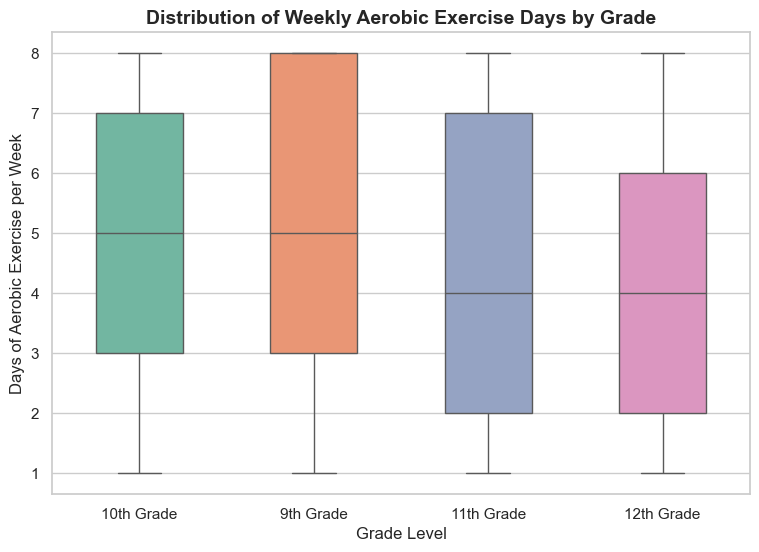

箱線圖已繪製並成功儲存為 'grade_exercise_boxplot.png'！


In [11]:
# 設定圖表風格與大小
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

# 繪製箱線圖，並用小提琴圖或點點做輔助（這裡用帶點的箱線圖，能清楚看出中位數與分佈）
sns.boxplot(x='Grade', y='Aerobic_Exercise', data=df_anova, palette='Set2', width=0.5)

# 設定標題與標籤
plt.title('Distribution of Weekly Aerobic Exercise Days by Grade', fontsize=14, fontweight='bold')
plt.xlabel('Grade Level', fontsize=12)
plt.ylabel('Days of Aerobic Exercise per Week', fontsize=12)

# 儲存圖片，方便之後上傳 GitHub
plt.savefig('grade_exercise_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()
print("箱線圖已繪製並成功儲存為 'grade_exercise_boxplot.png'！")

In [13]:
# 1. 建立 ANOVA 模型：運動天數 ~ 年級
model = ols('Aerobic_Exercise ~ C(Grade)', data=df_anova).fit()

# 2. 輸出 ANOVA 摘要表
anova_table = sm.stats.anova_lm(model, typ=2)
print("=================== ANOVA 檢定結果 ===================")
display(anova_table)

=================== ANOVA 檢定結果 ===================


,sum_sq,df,F,PR(>F)
C(Grade),1514.134816,3.0,81.809265,2.086895e-52
Residual,76728.451311,12437.0,NaN,NaN


In [17]:
# 進行 Tukey HSD 事後檢定
tukey = pairwise_tukeyhsd(endog=df_anova['Aerobic_Exercise'],
                          groups=df_anova['Grade'],
                          alpha=0.05)

print("=================== Tukey HSD 事後比較結果 ===================")
print(tukey)

=================== Tukey HSD 事後比較結果 ===================
    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
  group1     group2   meandiff p-adj   lower   upper  reject
------------------------------------------------------------
10th Grade 11th Grade  -0.3369    0.0 -0.4992 -0.1747   True
10th Grade 12th Grade  -0.6651    0.0 -0.8264 -0.5039   True
10th Grade  9th Grade   0.2585 0.0003  0.0945  0.4225   True
11th Grade 12th Grade  -0.3282    0.0  -0.488 -0.1685   True
11th Grade  9th Grade   0.5954    0.0  0.4329   0.758   True
12th Grade  9th Grade   0.9236    0.0  0.7621  1.0852   True
------------------------------------------------------------
